# Signal Investigation

It's finally time! The subsample is now quality controlled, mass-complete, binned into environment quartiles, binned by redshift and stellar mass, and binned into passive/active star formation!

## Finding signal

With quality-controlled, mass-complete subsamples, the search for environmental signals proceeds in a controlled hierarchy. Within each redshift bin and stellar mass bin, measure as a function of environment:

1. Passive fraction.

2. Median $D4000_n$.

3. $H\delta$ strength.

4. OII emission fractions.

Additionally, stellar class and morphological data can be used to find:

1. Fraction of elliptical vs spirals across environment quartiles.

2. What fraction of ellipticals are still spectrally star-forming (at fixed mass)?

3. What fraction of spirals are already passive?

    * Fraction of passive spirals as a function of density.

4. Count spectral classes in each density quartile


At fixed mass and fixed redshift, does increasing density correlate with older stellar populations or higher passive fractions?

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from collections import defaultdict
import pickle
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mode
import matplotlib as mlp
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import LinearSegmentedColormap
import os
import sys
sys.path.insert(0, "../")
import timescape_functions as tf

# Load analysis sample
analysis_sample = pd.read_csv('analysis_sample.csv')

# Reload z_bin and mass_bin as intervals
analysis_sample = tf.load_bin_intervals(analysis_sample, 0.2, 0.01)
# Merge spiral galaxies
analysis_sample["shape"] = analysis_sample["shape"].replace({
    "spiralclock": "spiral",
    "spiralanticlock": "spiral",
    "edgeon": "spiral"
})

# Load D4000n original data for valley_x value
oii_vals, oii_err_vals, hd_vals, hd_err_vals, d4000n_vals, d4000n_err_vals = tf.load_data('../pickle_folder/line_data.pkl')

p0 = [1000, 1.2, 0.08, 5000, 1.8, 0.006]
_, valley_x = tf.plot_best_fit(d4000n_vals, 0.05, 99.9, p0=p0, bins=300)

In [2]:
def create_contour_plots(analysis_sample, env_type, measured_param):
    """
    Parameters:
    -----------
    env_type -> "5NN" (5NN quartiles), "density" (num density quartiles), "overlap" (agreement between other metrics)

    measured_param -> "sf_type", "D4000n", "hd", "oii
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    #------------------------------------
    #
    # Handle different environment values
    #
    #------------------------------------

    if env_type == "5NN":
        envs = ["Overdense", "Intermediate 1", "Intermediate 2", "Underdense"]
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        envs = ['Underdense', 'Intermediate 2', 'Intermediate 1', 'Overdense']
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        envs = ["Overdense", "Intermediate 1", "Intermediate 2", "Underdense"]
        env_word = "Overlapping Quartile Agreement"
        image_split = "overlap"

    #----------------------------------------------------
    #
    # Handle grid creation for different parameter values
    #
    #----------------------------------------------------

    if measured_param == "sf_type":
        lambda_apply = "Passive"
        colorbar_label = "Passive Fraction" 
        image_name = f"../Images/{measured_param}/pass_f_contour_{image_split}.png"
        plt_title = rf"Passive Fraction by {env_word}"

        grid = (
        analysis_sample
        .groupby(["z_bin", "mass_bin", env_type], observed=True)[measured_param]
        .apply(lambda x: (x==lambda_apply).mean())
        .reset_index(name="f")
    )

    elif measured_param == "D4000n":
        colorbar_label = r"Median $D4000_n$"
        image_name = f"../Images/{measured_param}/d4000n_contour_{image_split}.png"
        plt_title = fr"Median $D4000_n$ contour plot by {env_word}"
        grid = (
            analysis_sample
            .groupby(["z_bin", "mass_bin", env_type], observed=True)[measured_param]
            .median()
            .reset_index(name="f")
        )
        all_vals = grid['f'].values
        finite_vals = all_vals[~np.isnan(all_vals)]
        vmin = finite_vals.min()
        vmax = finite_vals.max()
        vcenter = valley_x
        norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    elif measured_param == "hd":
        colorbar_label = r"Median $W_0[H\delta]$"
        image_name = f"../Images/{measured_param}/hd_contour_{image_split}.png"
        plt_title = fr"Median $W_0[H\delta]$ contour plot by {env_word}"
        grid = (
            analysis_sample
            .groupby(["z_bin", "mass_bin", env_type], observed=True)[measured_param]
            .median()
            .reset_index(name="f")
        )
    
    elif measured_param == "oii":
        colorbar_label = r"Median $W_0[OII]$"
        image_name = f"../Images/{measured_param}/oii_contour_{image_split}.png"
        plt_title = fr"Median $W_0[OII]$ contour plot by {env_word}"
        grid = (
            analysis_sample
            .groupby(["z_bin", "mass_bin", env_type], observed=True)[measured_param]
            .median()
            .reset_index(name="f")
        )
    
    #--------------------------------------------------
    #
    # Handle plotting for each env_type/parameter combo
    #
    #--------------------------------------------------

    for ax, env in zip(axes, envs):
        sub = grid[grid[env_type]==env].copy()
        if env == "Unknown":
            continue
        sub["z_center"] = sub["z_bin"].apply(lambda x: x.mid)
        sub["mass_center"] = sub["mass_bin"].apply(lambda x: x.mid)

        pivot = sub.pivot(
            index = "mass_center",
            columns = "z_center",
            values = "f"
        )

        Z = pivot.values
        Z_masked = np.ma.masked_invalid(Z)

        if measured_param == "sf_type":
            cf = ax.contourf(
                pivot.columns,
                pivot.index,
                Z_masked,
                levels=20
            )

        elif measured_param == "D4000n":
            cf = ax.contourf(
                pivot.columns,
                pivot.index,
                Z_masked,
                levels=20,
                norm=norm,
                cmap="seismic"
            )

        elif measured_param == "hd":
            cf = ax.contourf(
                pivot.columns,
                pivot.index,
                Z_masked,
                levels=20,
                cmap="inferno"
            )

        elif measured_param == "oii":
            cf = ax.contourf(
                pivot.columns,
                pivot.index,
                Z_masked,
                levels=20,
                cmap="berlin"
            )

        ax.set_xlabel("Redshift")
        ax.set_ylabel(r"$\log(M)$")
        ax.set_title(env)

    plt.colorbar(cf, ax=axes, label=colorbar_label)
    fig.suptitle(plt_title)
    os.makedirs(f"../Images/{measured_param}", exist_ok=True)
    plt.savefig(image_name)
    plt.show()

    return grid

def create_difference_map(grid, env_type, measured_param):
    """
    Parameters:
    -----------
    env_type -> "5NN" (5NN quartiles), "density" (num density quartiles)

    measured_param -> "sf_type", "D4000n", "hd", "oii
    """
    if env_type == "5NN":
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        env_word = "Overlapping Quartile Agreement"
        image_split = "overlap"

    cluster = grid[grid[env_type]=="Overdense"]
    void    = grid[grid[env_type]=="Underdense"]

    merged_env = cluster.merge(
        void,
        on=["z_bin", "mass_bin"],
        suffixes=("_cluster", "_void")
    )

    merged_env["delta"] = (
        merged_env["f_cluster"] - merged_env["f_void"]
    )

    if measured_param == "sf_type":
        colorbar_label = r"$\Delta f$"
        print_word = "Delta frac"
        plt_title = rf"$\Delta f$ by {env_word}"
        image_name = f"../Images/{measured_param}/passive_f_difference_{image_split}.png"

    elif measured_param == "D4000n":
        colorbar_label = r"$\Delta D4000_n$"
        print_word = "Delta D4000n"
        plt_title = rf"$\Delta D4000_n$ by {env_word}"
        image_name = f"../Images/{measured_param}/d4000n_difference_{image_split}.png"

    elif measured_param == "hd":
        colorbar_label = r"$\Delta W_0[H\delta]$"
        print_word = "Delta Hd"
        plt_title = rf"$\Delta W_0[H\delta]$ by {env_word}"
        image_name = f"../Images/{measured_param}/hd_difference_{image_split}.png"

    elif measured_param == "oii":
        colorbar_label = r"$\Delta W_0[O\text{ }II]$"
        print_word = "Delta OII"
        plt_title = rf"$\Delta W_0[OII]$ by {env_word}"
        image_name = f"../Images/{measured_param}/oii_difference_{image_split}.png"


    print(f"{print_word} mean: {merged_env['delta'].mean():.3f} \pm {merged_env['delta'].std():.3f}")
    print(f"{print_word} min: {merged_env['delta'].min():.3f}")
    print(f"{print_word} max: {merged_env['delta'].max():.3f}")

    merged_env = merged_env.copy()
    merged_env["z_center"] = merged_env["z_bin"].apply(lambda x: x.mid)
    merged_env["mass_center"] = merged_env["mass_bin"].apply(lambda x: x.mid)
    pivot = merged_env.pivot(
        index="mass_center",
        columns="z_center",
        values="delta"
    )
    
    Z = np.ma.masked_invalid(pivot.values)
    #Z = pivot.values

    v = np.nanmax(np.abs(Z))
    if np.isnan(v) or v == 0:
        v = 1e-6

    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
    
    plt.contourf(
        pivot.columns,
        pivot.index,
        Z,
        levels=20,
        cmap="RdBu_r",
        norm=norm
    )

    plt.xlabel("Redshift")
    plt.ylabel(r"$\log(M)$")
    plt.title(plt_title)
    plt.colorbar(label=colorbar_label)
    plt.tight_layout()
    os.makedirs(f"../Images/{measured_param}", exist_ok=True)
    plt.savefig(image_name)
    plt.show()

def plot_quartiles_by_redshift_and_mass(analysis_sample, env_type, measured_param):
    """
    Parameters:
    -----------
    env_type -> "5NN" (5NN quartiles), "density" (num density quartiles)

    measured_param -> "sf_type", "D4000n", "hd", "oii
    """
    if env_type == "5NN":
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        env_word = "Overlapping Quartile Agreement"
        image_split = "overlap"

    z_grouped    = analysis_sample.groupby(["z_bin", env_type], observed=True)
    mass_grouped = analysis_sample.groupby(["mass_bin", env_type], observed=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=False, sharex=False)

    if measured_param == "sf_type":
        ylabel="Passive Fraction"
        ax1_title = r"Passive fraction evolution over redshift"
        ax2_title = r"Passive fraction evolution across stellar mass"
        image_name = f"../Images/{measured_param}/{measured_param}_z_mass_{image_split}.png"
        z_stats = z_grouped[measured_param].agg(
            N="count",
            f=lambda x: (x=="Passive").mean()
        ).reset_index()
        z_stats["z_center"] = z_stats["z_bin"].apply(lambda x: x.mid)
        z_stats["sigma_f"] = np.sqrt(z_stats["f"] * (1-z_stats["f"]) / z_stats["N"])
        for env in z_stats[env_type].unique():
            if env == "Unknown":
                continue
            sub = z_stats[z_stats[env_type]==env]
            ax1.errorbar(
                sub["z_center"],
                sub["f"],
                yerr=sub["sigma_f"],
                label=f"{env} ({sub['N'].sum()})"
            )
        
        mass_stats = mass_grouped[measured_param].agg(
            N="count",
            f=lambda x: (x=="Passive").mean()
        ).reset_index()
        mass_stats["mass_center"] = mass_stats["mass_bin"].apply(lambda x: x.mid)
        mass_stats["sigma_f"] = np.sqrt(mass_stats["f"] * (1-mass_stats["f"]) / mass_stats["N"])
        for env in mass_stats[env_type].unique():
            if env == "Unknown":
                continue
            sub = mass_stats[mass_stats[env_type]==env]
            ax2.errorbar(
                sub["mass_center"],
                sub["f"],
                yerr=sub["sigma_f"],
                label=f"{env} ({sub['N'].sum()})"
            )
    
    else:
        if measured_param == "D4000n":
            ax1_title = r"Median $D4000_n$ evolution over redshift"
            ax2_title = r"Median $D4000_n$ evolution across stellar mass"
            ylabel = r"Median $D4000_n$"
            image_name = f"../Images/{measured_param}/d4000n_z_mass_{image_split}.png"

        elif measured_param == "hd":
            ax1_title = r"Median $W_0[H\delta]$ evolution over redshift"
            ax2_title = r"Median $W_0[H\delta]$ evolution across stellar mass"
            ylabel = r"Median $W_0[H\delta]$"
            image_name = f"../Images/{measured_param}/hd_z_mass_{image_split}.png"

        elif measured_param == "oii":
            ax1_title = r"Median $W_0[OII]$ evolution over redshift"
            ax2_title = r"Median $W_0[OII]$ evolution across stellar mass"
            ylabel = r"Median $W_0[OII]$"
            image_name = f"../Images/{measured_param}/oii_z_mass_{image_split}.png"

        z_stats = z_grouped[measured_param].agg(
            N="count",
            median="median",
            std="std"
        ).reset_index()

        z_stats["yerr"] = z_stats["std"] / np.sqrt(z_stats["N"])
        z_stats["z_center"] = z_stats["z_bin"].apply(lambda x: x.mid)
        for env, sub in z_stats.groupby(env_type):
            if env == "Unknown":
                continue
            sub = sub.sort_values("z_center")
            ax1.errorbar(
                sub["z_center"],
                sub["median"],
                yerr=sub["yerr"],
                label=f"{env} ({sub['N'].sum()})"
            )

        mass_stats = mass_grouped[measured_param].agg(
            N="count",
            median="median",
            std="std"
        ).reset_index()

        mass_stats["yerr"] = mass_stats["std"] / np.sqrt(mass_stats["N"])
        mass_stats["mass_center"] = mass_stats["mass_bin"].apply(lambda x: x.mid)
        for env, sub in mass_stats.groupby(env_type):
            if env == "Unknown":
                continue
            sub = sub.sort_values("mass_center")
            ax2.errorbar(
                sub["mass_center"],
                sub["median"],
                yerr=sub["yerr"],
                label=f"{env} ({sub['N'].sum()})"
            )

    if measured_param == "D4000n":
        ax1.axhline(valley_x, linestyle='dashed')
        ax2.axhline(valley_x, linestyle='dashed')

    ax1.set_xlabel("Redshift")
    ax1.set_ylabel(ylabel)
    ax1.set_title(ax1_title)
    ax2.set_title(ax2_title)
    ax2.set_xlabel("$\log(M)$")
    fig.suptitle(f"Evolution across redshift and mass, binned by {env_word}")
    plt.legend()
    plt.tight_layout()
    os.makedirs(f"../Images/{measured_param}/", exist_ok=True)
    plt.savefig(image_name)
    plt.show()

# Compare Passive Fraction Evolution

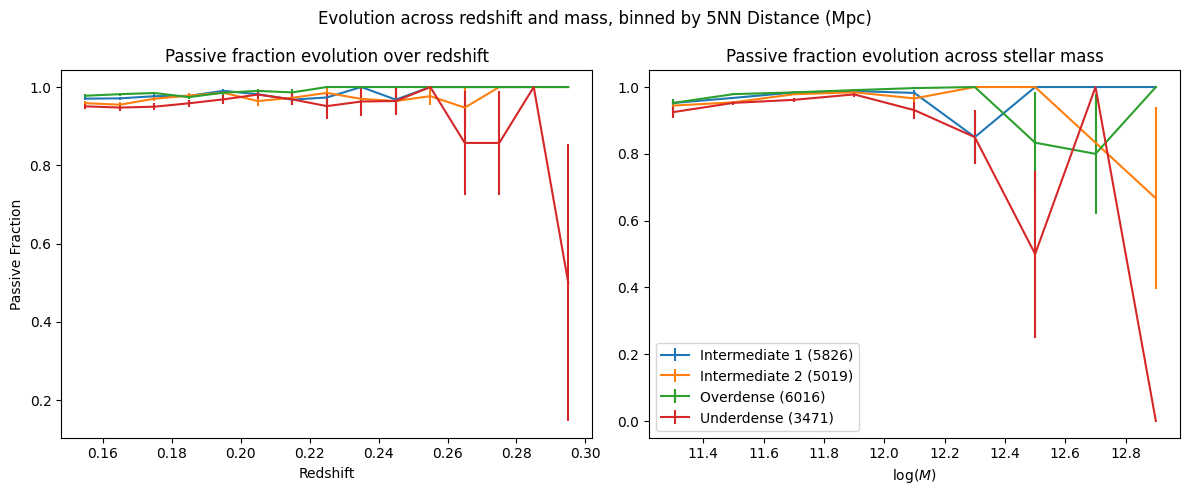

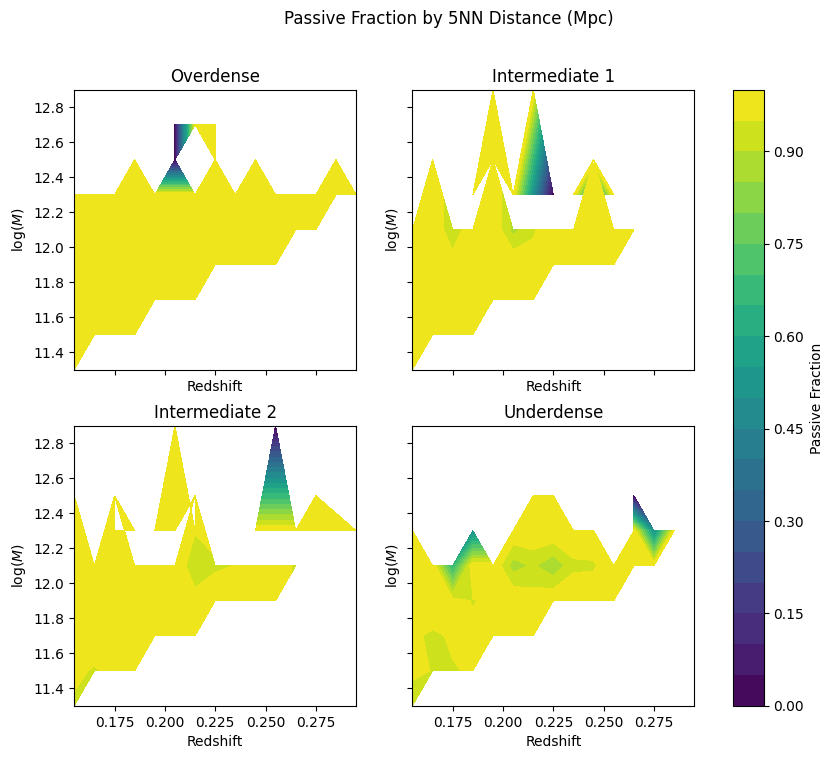

Delta frac mean: 0.055 \pm 0.129
Delta frac min: -0.033
Delta frac max: 0.500


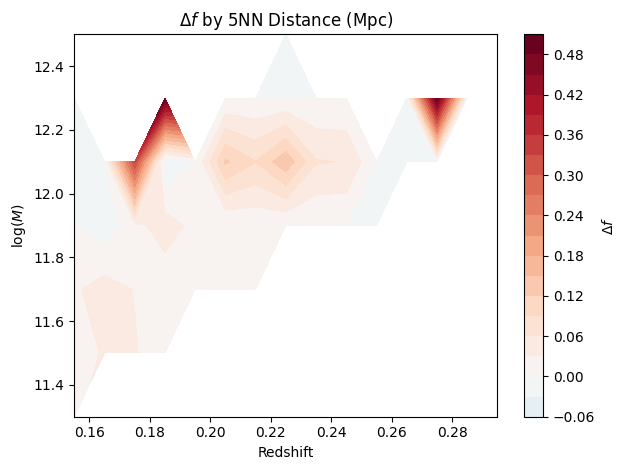

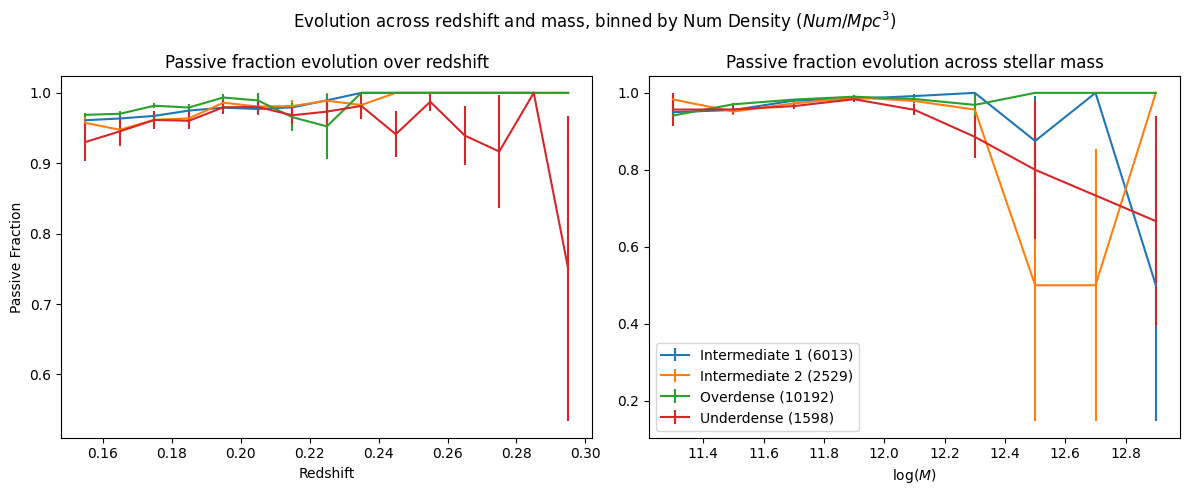

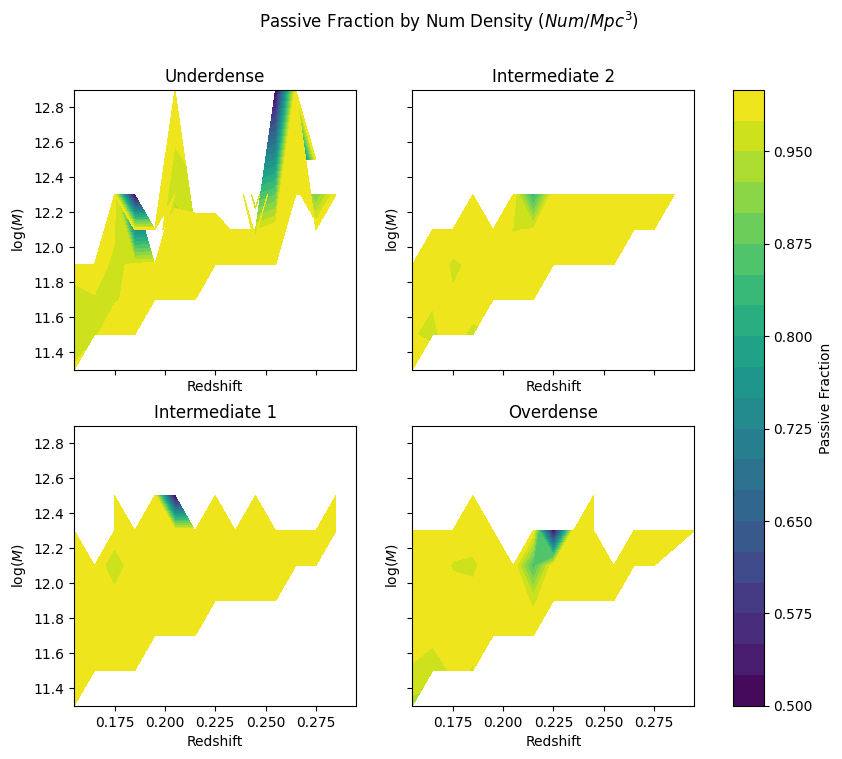

Delta frac mean: 0.040 \pm 0.182
Delta frac min: -0.500
Delta frac max: 1.000


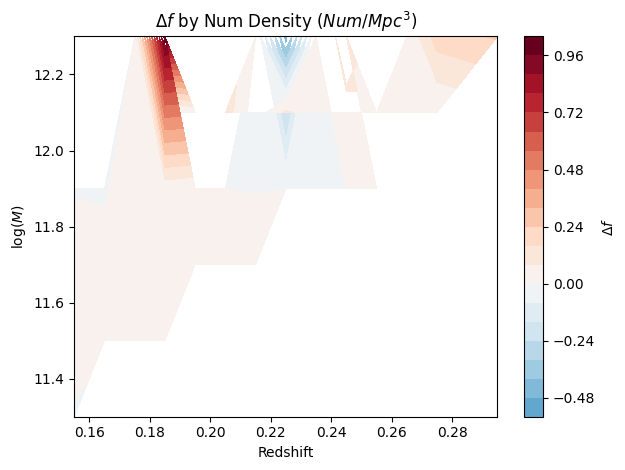

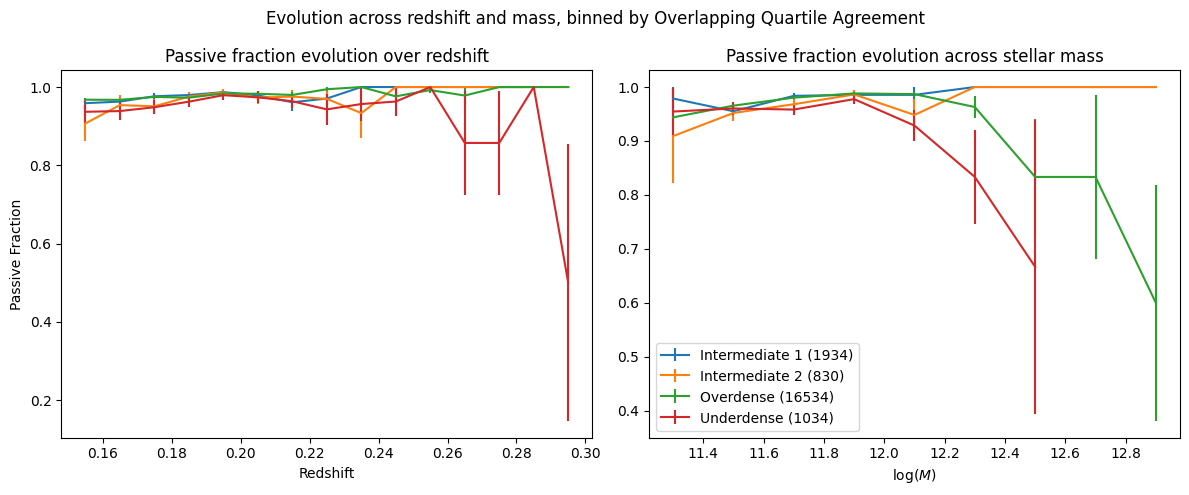

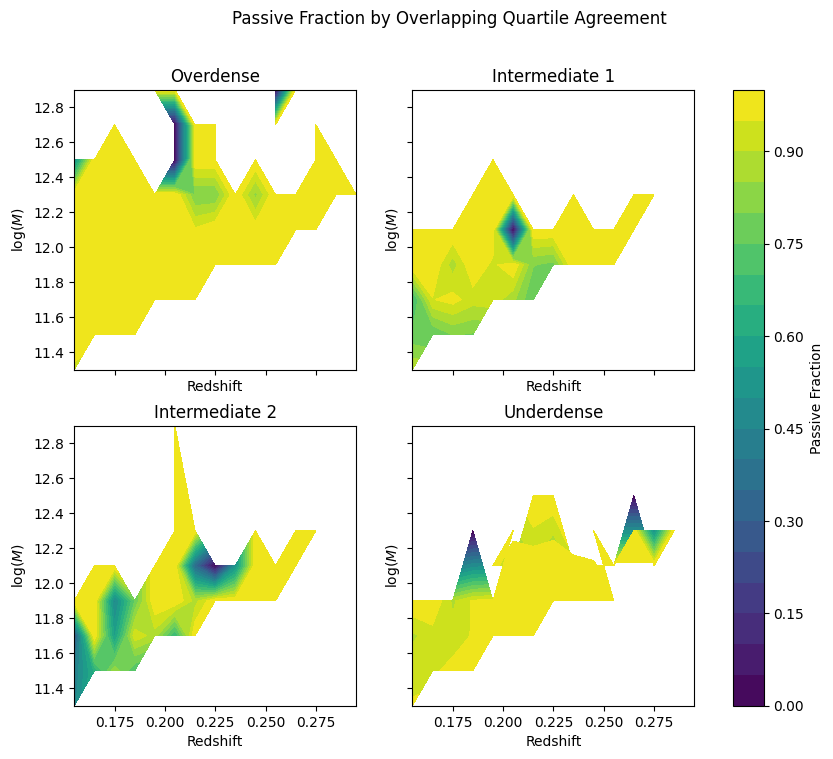

Delta frac mean: 0.053 \pm 0.192
Delta frac min: -0.200
Delta frac max: 1.000


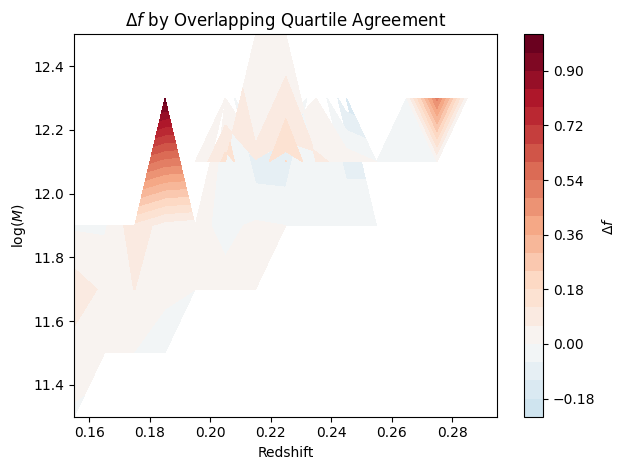

In [3]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_quartiles_by_redshift_and_mass(analysis_sample, env, "sf_type")
    grid = create_contour_plots(analysis_sample, env, "sf_type")
    create_difference_map(grid, env, "sf_type")

# Compare median $D4000_n$ evolution

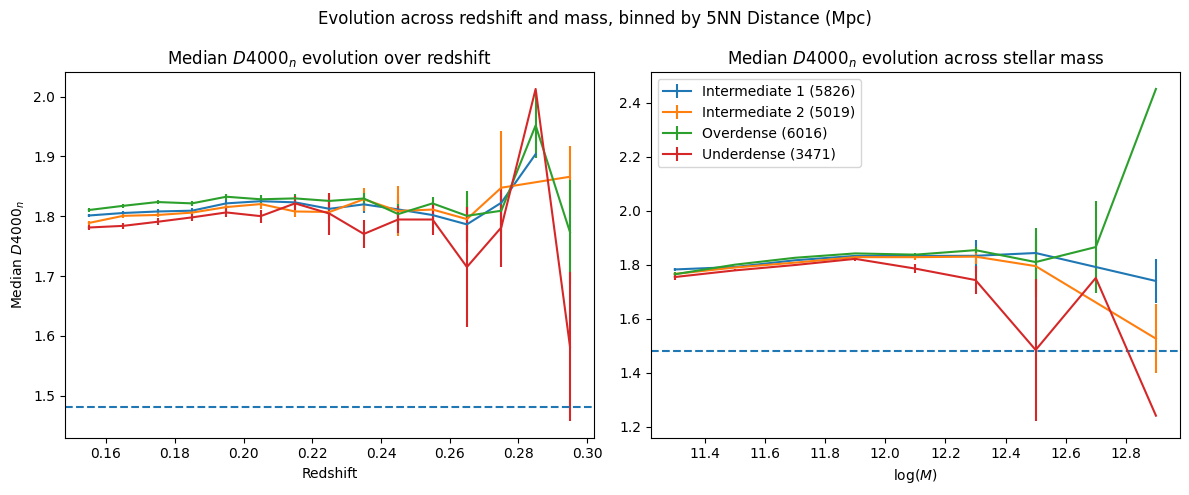

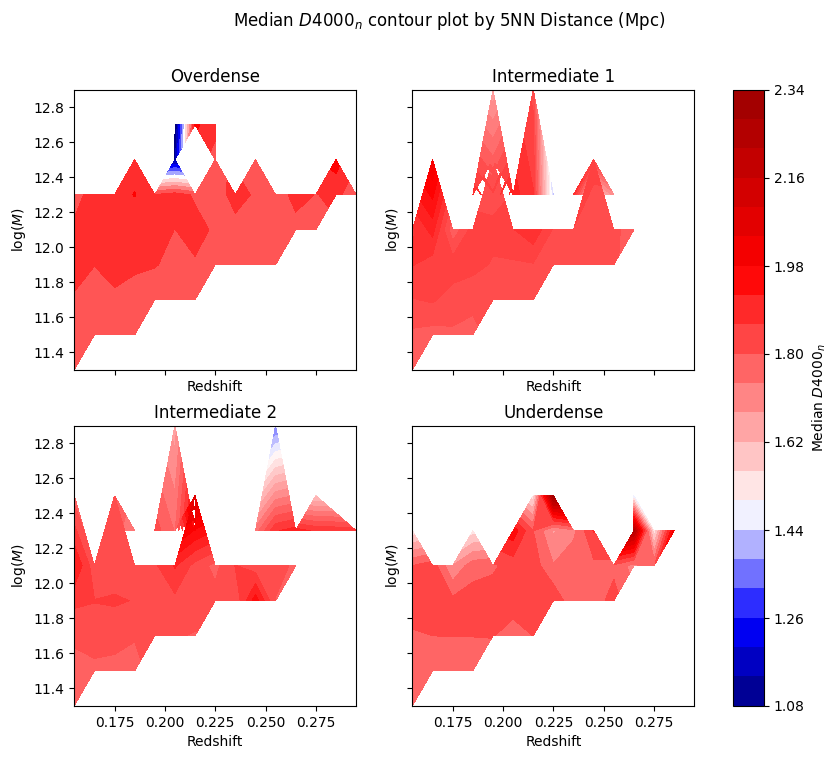

Delta D4000n mean: 0.034 \pm 0.136
Delta D4000n min: -0.525
Delta D4000n max: 0.389


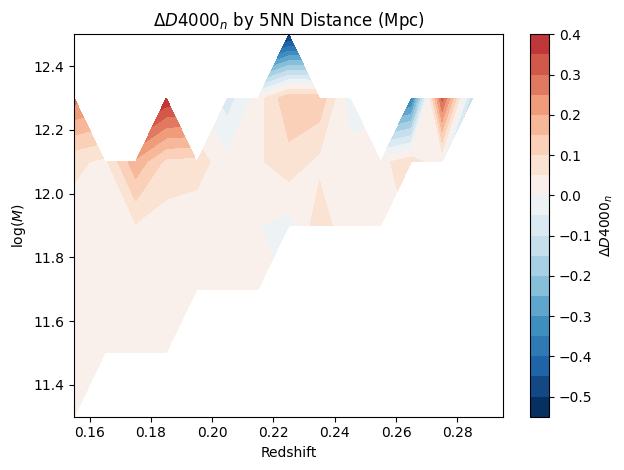

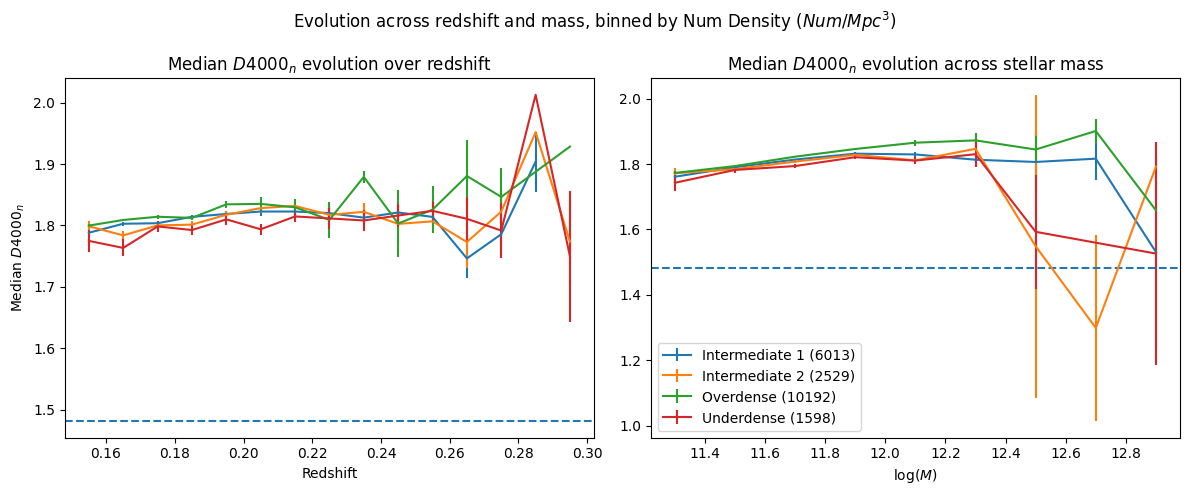

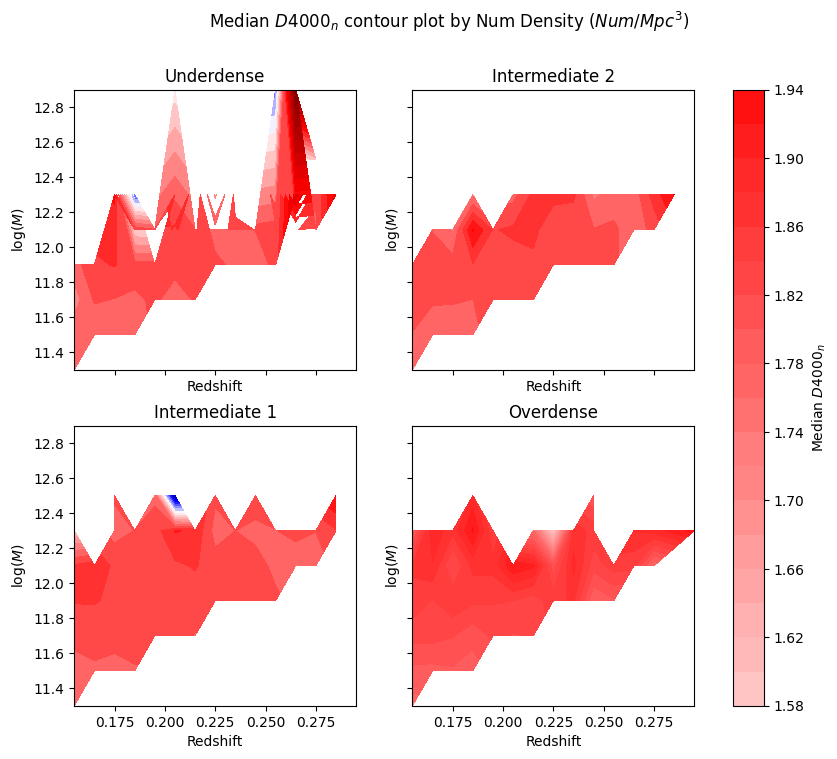

Delta D4000n mean: 0.036 \pm 0.109
Delta D4000n min: -0.191
Delta D4000n max: 0.617


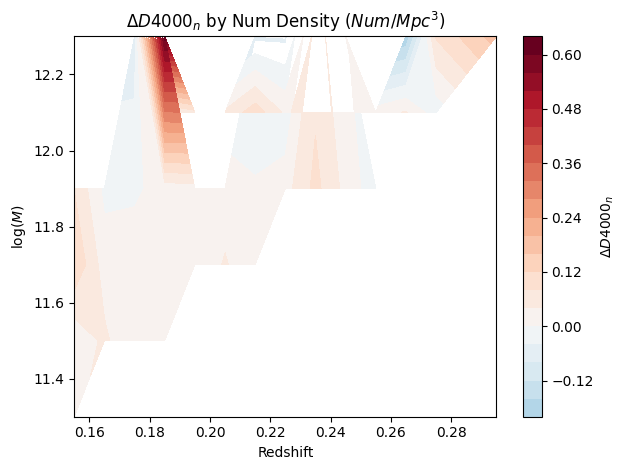

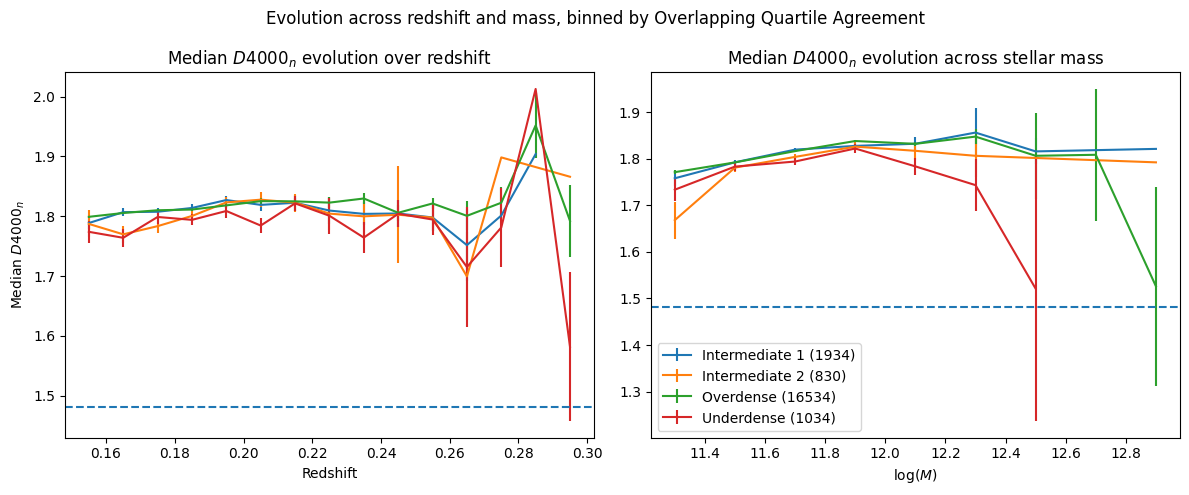

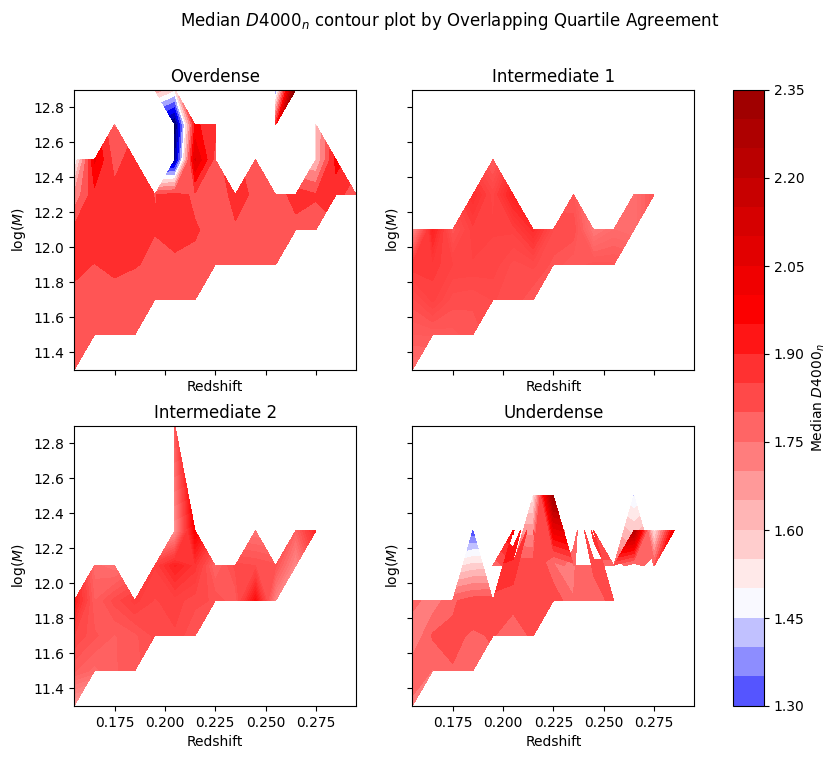

Delta D4000n mean: 0.044 \pm 0.174
Delta D4000n min: -0.525
Delta D4000n max: 0.601


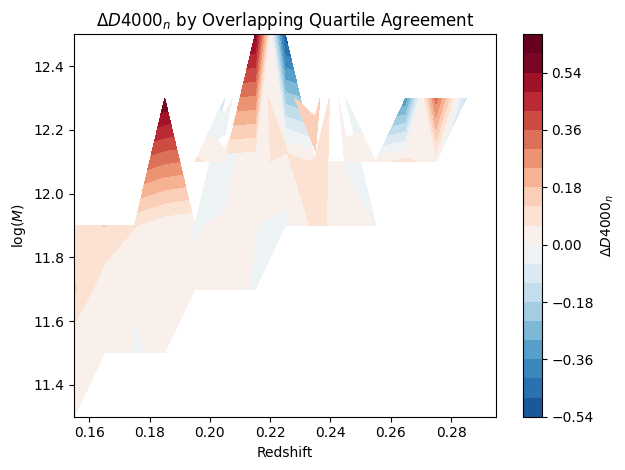

In [4]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_quartiles_by_redshift_and_mass(analysis_sample, env, "D4000n")
    grid = create_contour_plots(analysis_sample, env, "D4000n")
    create_difference_map(grid, env, "D4000n")

# Compare median $W_0[H\delta]$ strength evolution

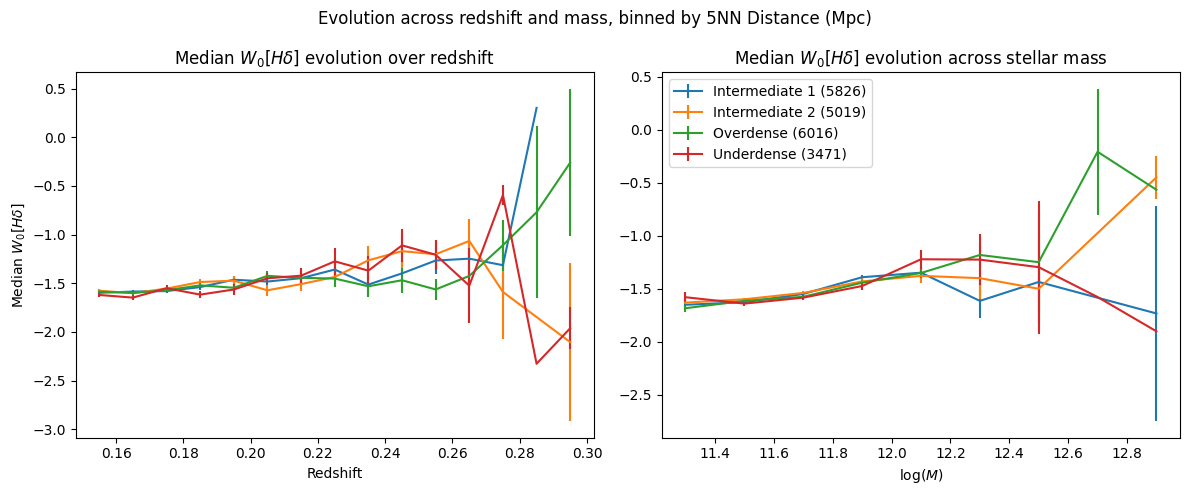

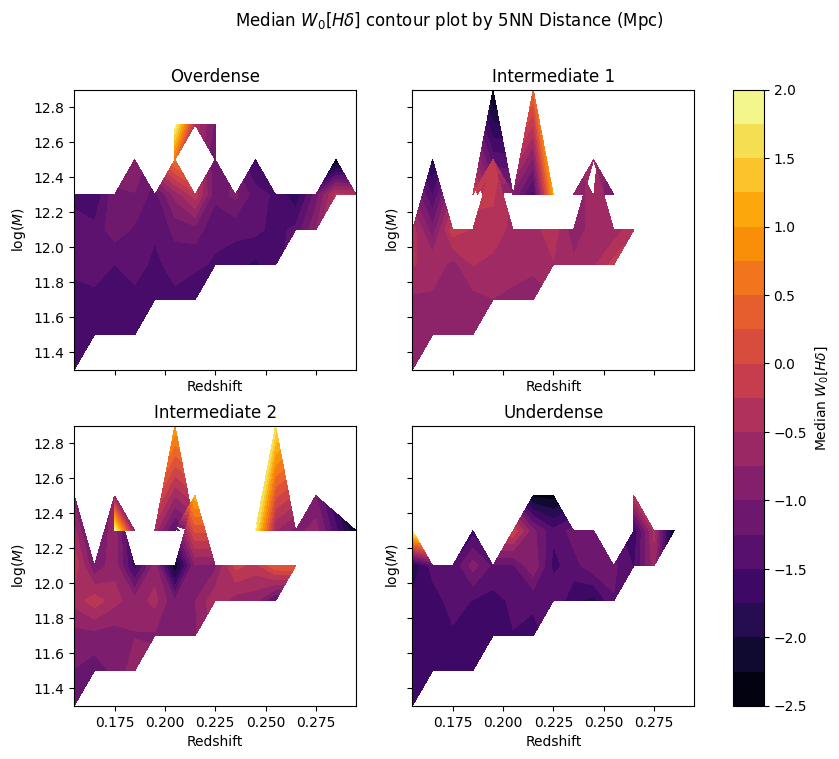

Delta Hd mean: 0.020 \pm 0.730
Delta Hd min: -3.533
Delta Hd max: 2.166


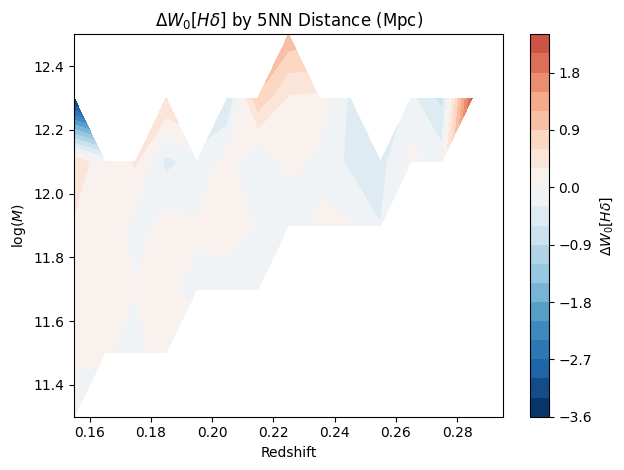

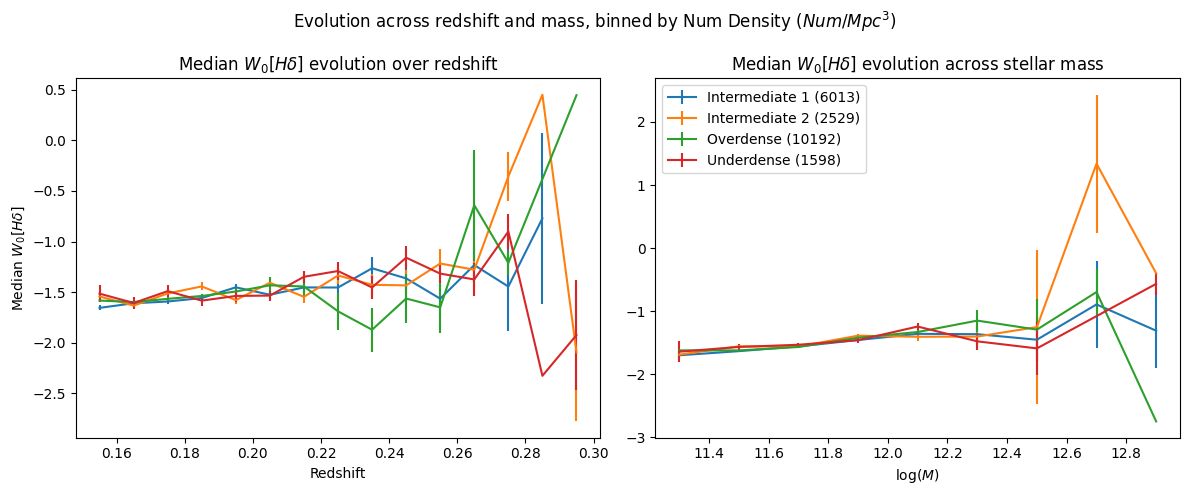

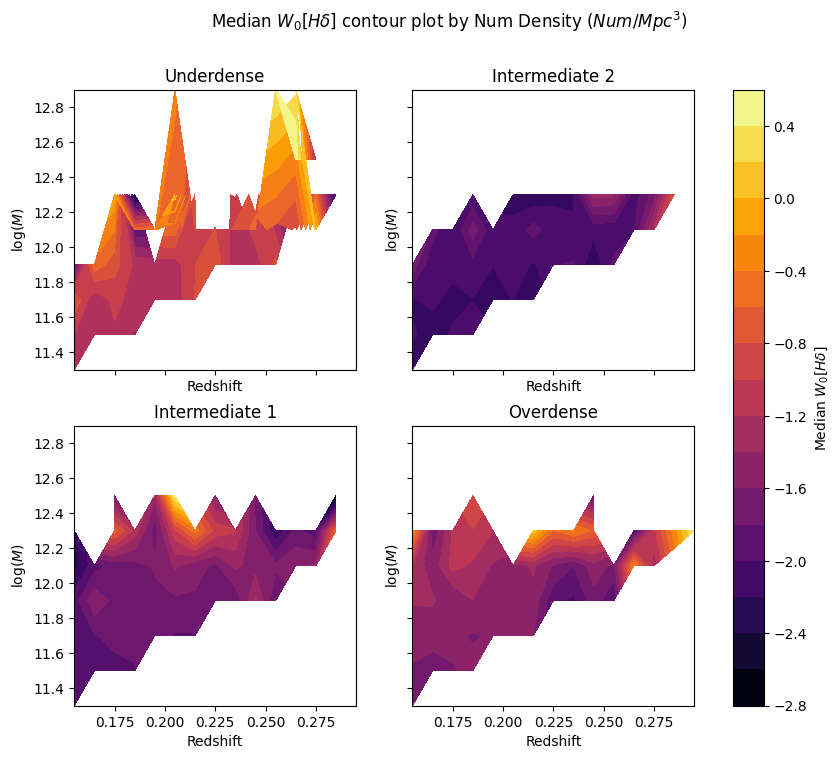

Delta Hd mean: 0.091 \pm 0.639
Delta Hd min: -0.699
Delta Hd max: 2.370


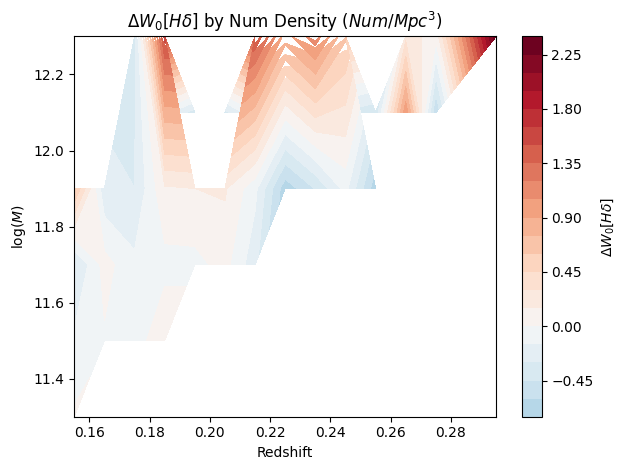

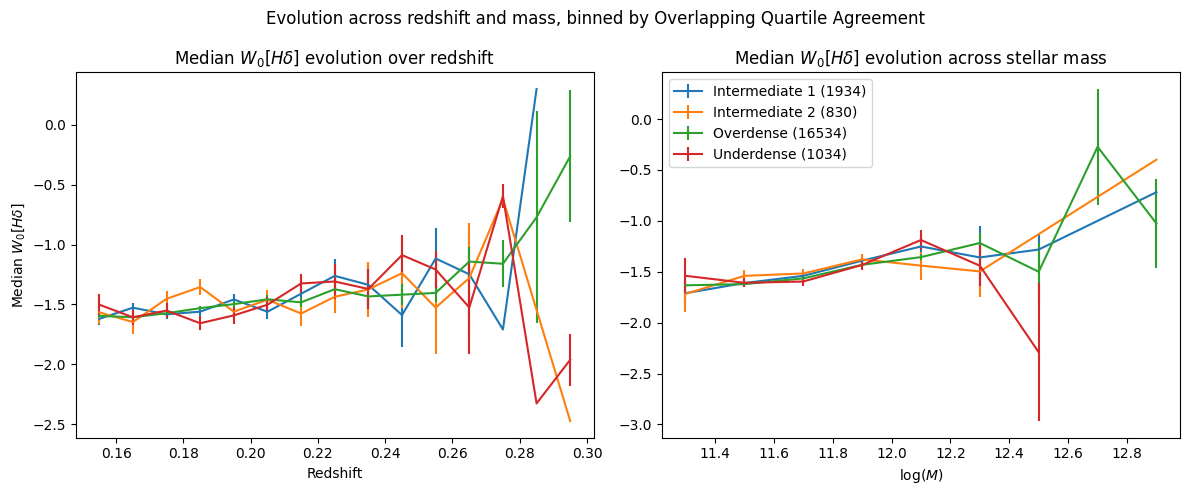

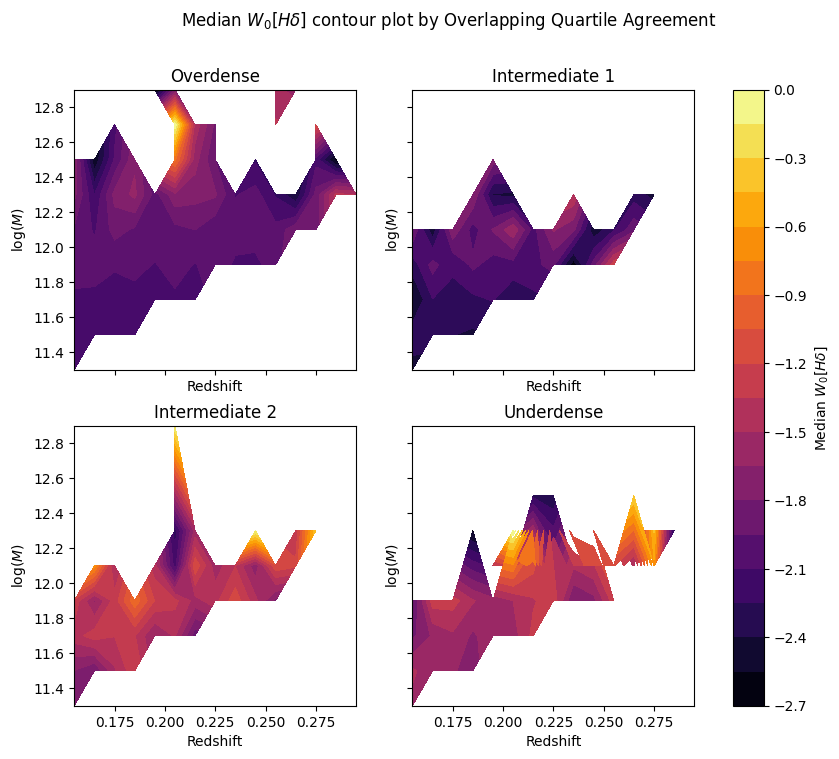

Delta Hd mean: 0.135 \pm 0.647
Delta Hd min: -0.768
Delta Hd max: 2.166


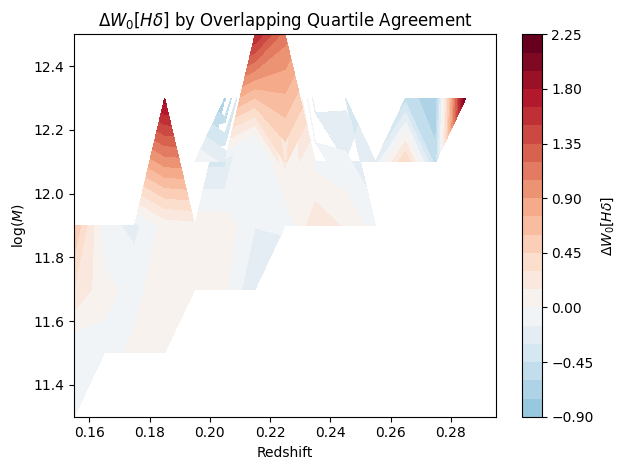

In [5]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_quartiles_by_redshift_and_mass(analysis_sample, env, "hd")
    grid = create_contour_plots(analysis_sample, env, "hd")
    create_difference_map(grid, env, "hd")

# Compare median $W_0[OII]$ evolution

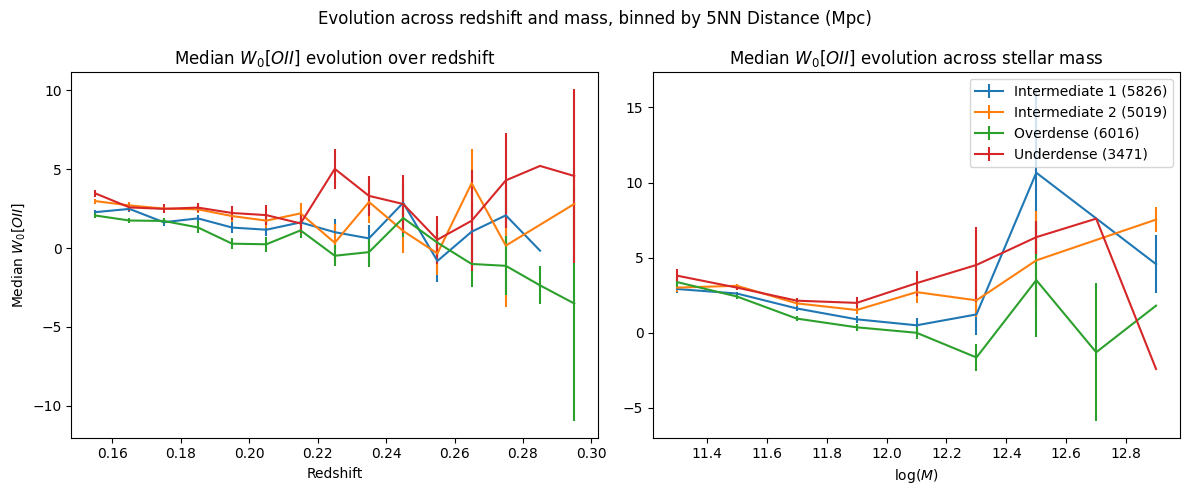

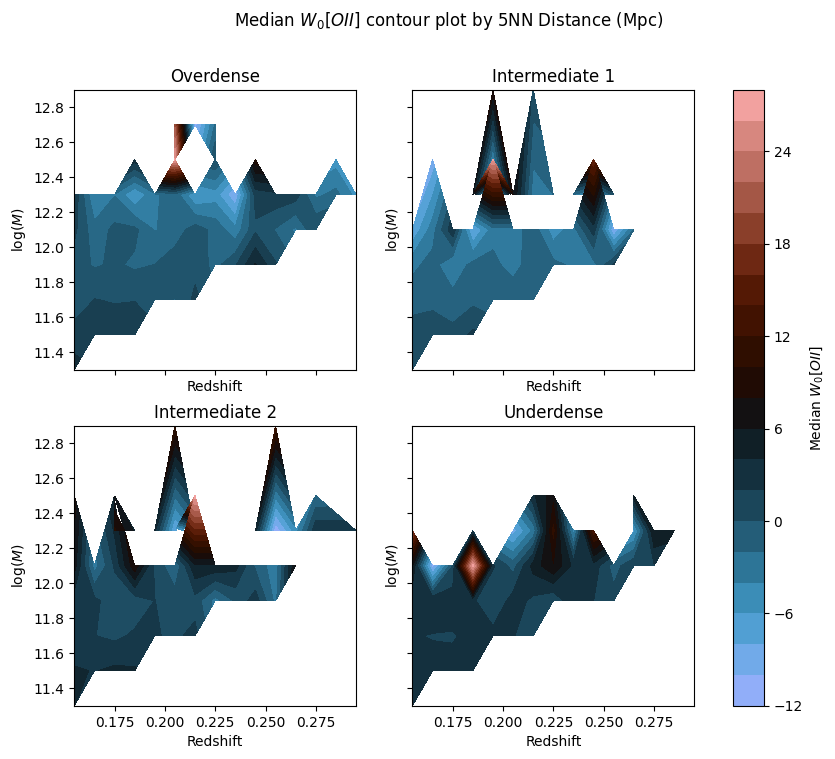

Delta OII mean: -2.772 \pm 5.954
Delta OII min: -26.573
Delta OII max: 10.109


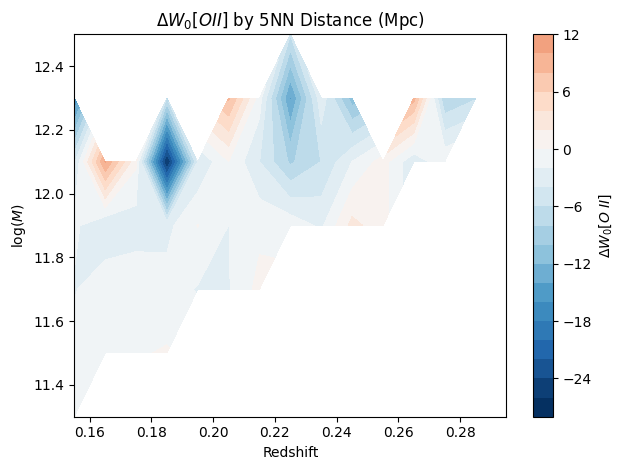

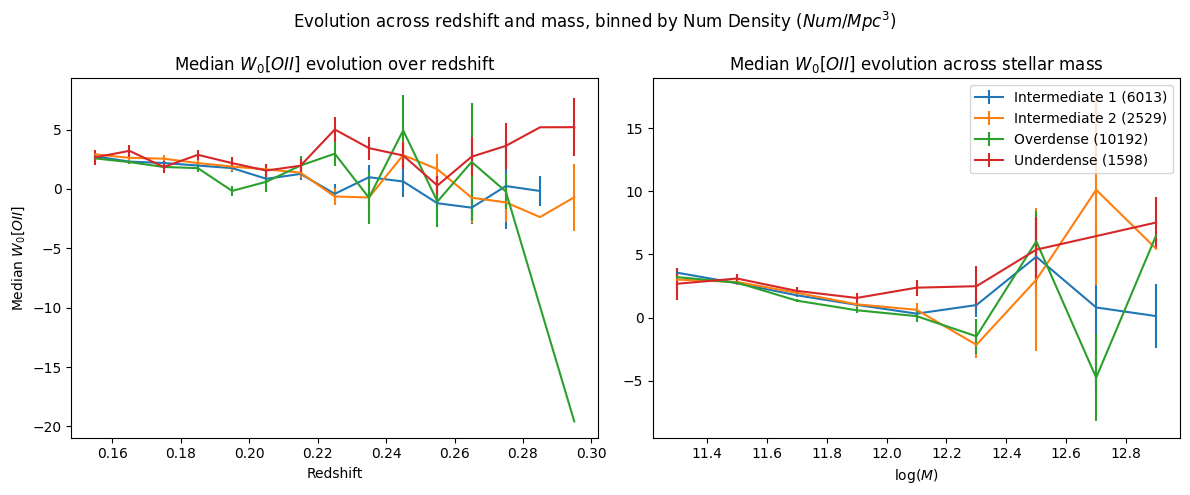

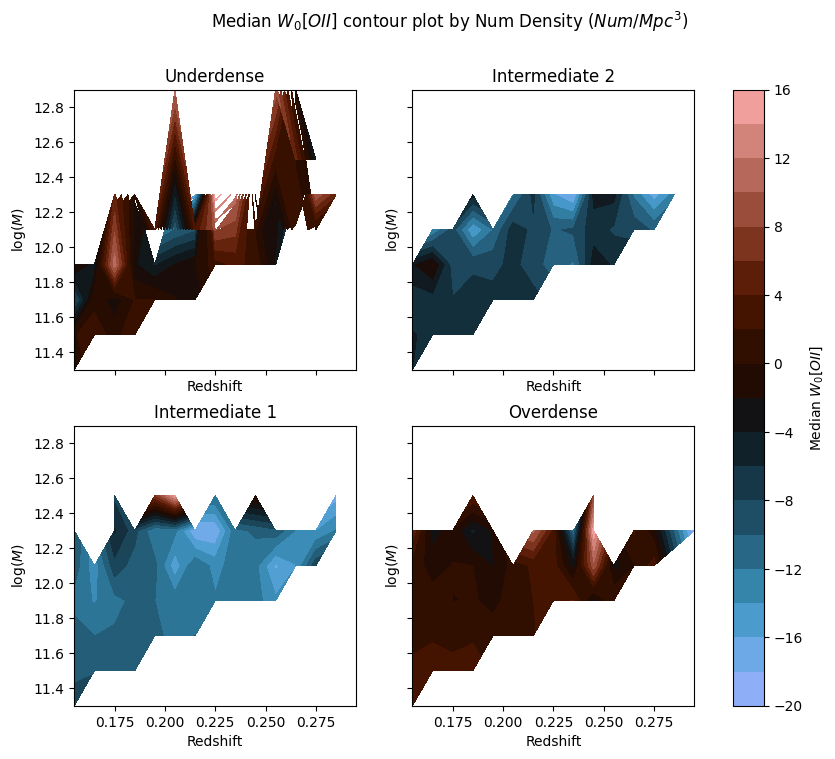

Delta OII mean: -1.721 \pm 6.868
Delta OII min: -24.791
Delta OII max: 16.866


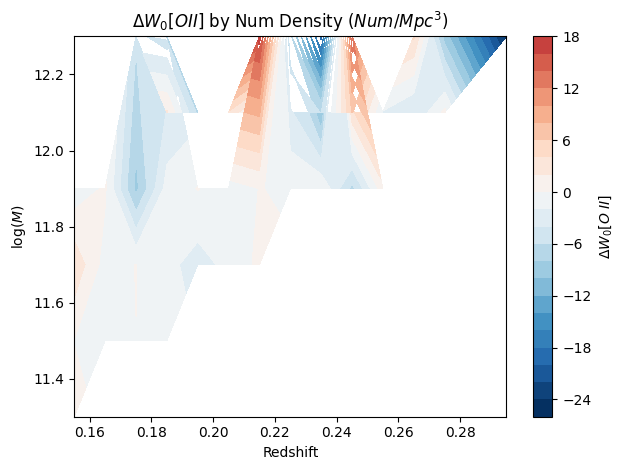

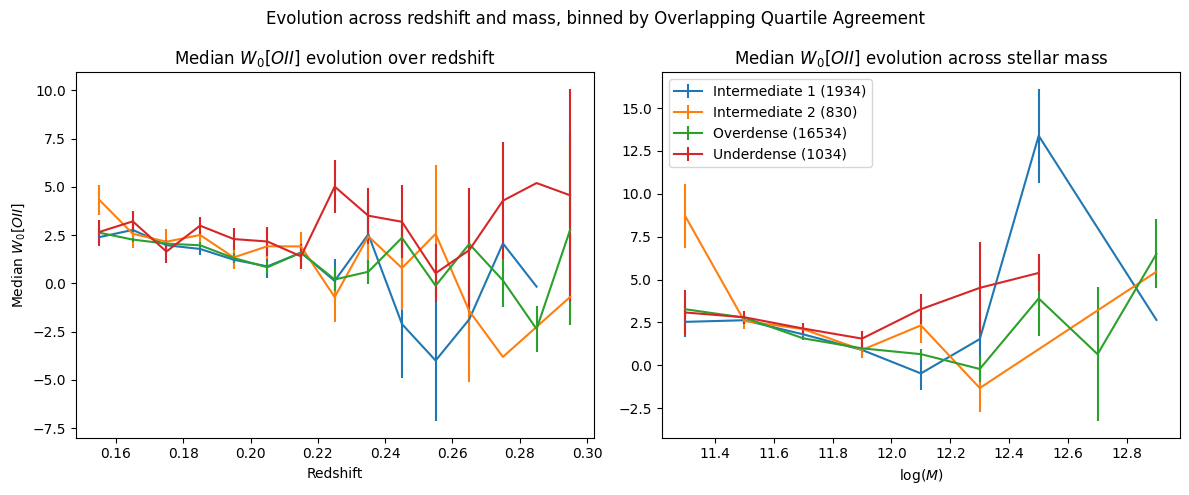

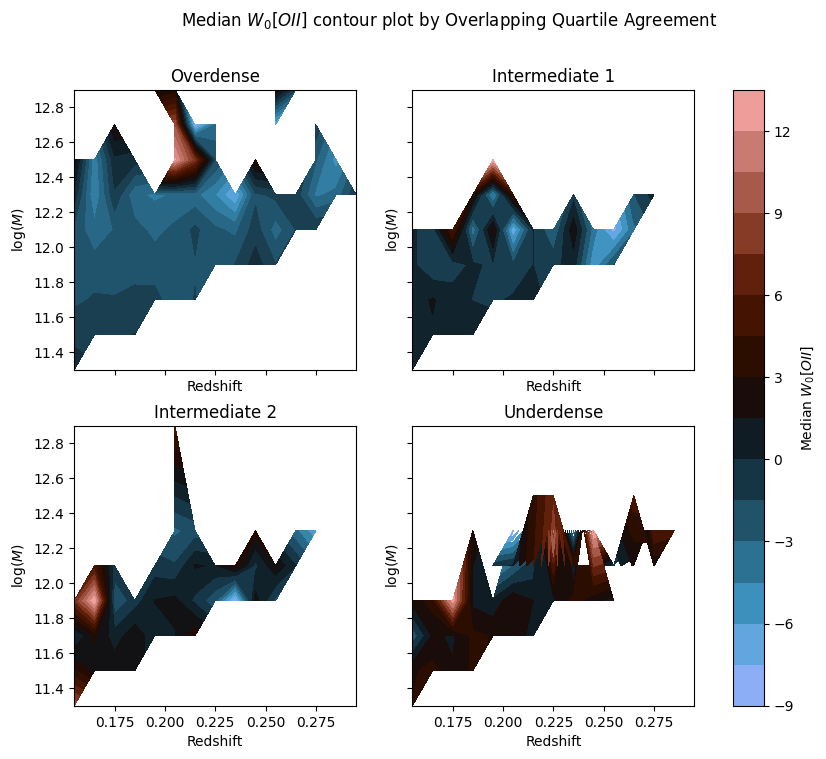

Delta OII mean: -1.206 \pm 4.784
Delta OII min: -13.577
Delta OII max: 11.855


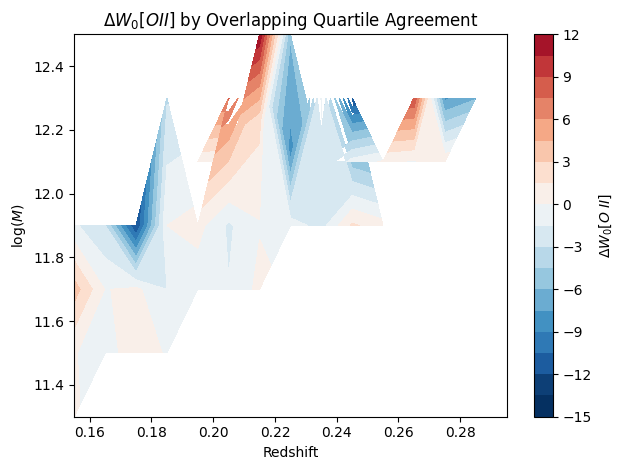

In [6]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_quartiles_by_redshift_and_mass(analysis_sample, env, "oii")
    grid = create_contour_plots(analysis_sample, env, "oii")
    create_difference_map(grid, env, "oii")

# Investigate how environment effects distributions of galaxies by class and shape

In [7]:
def plot_population_vs_environment(analysis_sample, env_type, population_type):
    """
    Parameters
    ----------
    env_type -> "5NN", "density", "overlap"
    population_type -> "class", "shape"
    """
    col = population_type

    if env_type == "5NN":
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        env_word = "Environment quartiles by overlapping agreement"
        image_split = "overlap"

    if population_type == "class":
        title = "Galaxy Class Counts vs Environment"
        image_name = f"../Images/populations/class_vs_env_{image_split}.png"

    elif population_type == "shape":
        title = "Galaxy Morphology Counts vs Environment"
        image_name = f"../Images/populations/shape_vs_env_{image_split}.png"

    df = analysis_sample.copy()
    df = df[df[env_type] != "Unknown"]

    quartile_order = [
        "Overdense",
        "Intermediate 1",
        "Intermediate 2",
        "Underdense"
    ]

    df[env_type] = pd.Categorical(df[env_type], categories=quartile_order, ordered=True)

    counts = (
        df.groupby([env_type, col], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(quartile_order)
    )

    N = counts.sum(axis=1)

    percent = counts.div(N, axis=0) * 100
    frac = counts.div(N, axis=0)
    sigma = np.sqrt(frac * (1 - frac) / N.values[:, None]) * 100

    print(f"N:\n",N)
    print(f"percent:\n",percent)
    print(f"sigma:\n",sigma)
    print()

    x = np.arange(len(quartile_order))

    for population in percent.columns:
        
        plt.errorbar(
            x,
            percent[population],
            yerr=sigma[population],
            label="unknown" if population == "dontknow" else population
        )

    plt.xticks(x, quartile_order, rotation=30)
    plt.ylabel("Fraction of sample (%)")
    plt.legend()

    title = env_word
    plt.title(title)
    plt.tight_layout()

    os.makedirs("../Images/populations/", exist_ok=True)
    plt.savefig(image_name)
    plt.show()

N:
 overlap
Overdense         254
Intermediate 1     20
Intermediate 2     17
Underdense         42
dtype: int64
percent:
 shape            dontknow  elliptical     spiral
overlap                                         
Overdense       24.803150   69.291339   5.905512
Intermediate 1  25.000000   60.000000  15.000000
Intermediate 2  17.647059   82.352941   0.000000
Underdense      16.666667   78.571429   4.761905
sigma:
 shape           dontknow  elliptical    spiral
overlap                                       
Overdense       2.709795    2.894363  1.479088
Intermediate 1  9.682458   10.954451  7.984360
Intermediate 2  9.245944    9.245944  0.000000
Underdense      5.750546    6.331466  3.286026



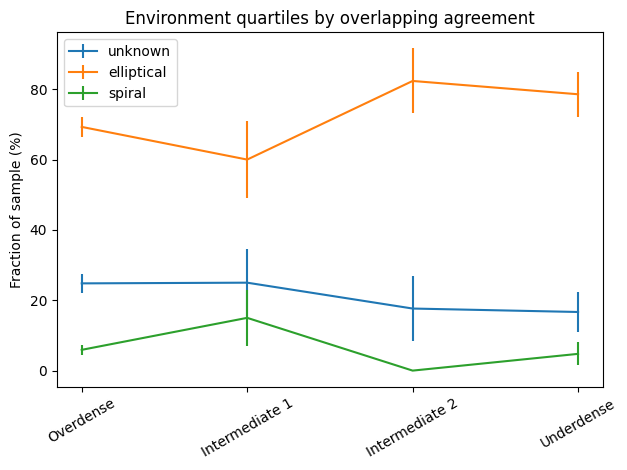

In [8]:
plot_population_vs_environment(analysis_sample, "overlap", "shape")


N:
 overlap
Overdense         16534
Intermediate 1     1934
Intermediate 2      830
Underdense         1034
dtype: int64
percent:
 class               e(b)       e(c)          k
overlap                                       
Overdense       0.048385  88.363372  11.588242
Intermediate 1  0.051706  85.470527  14.477766
Intermediate 2  0.000000  87.951807  12.048193
Underdense      0.000000  88.201161  11.798839
sigma:
 class               e(b)      e(c)         k
overlap                                     
Overdense       0.017103  0.249379  0.248929
Intermediate 1  0.051693  0.801318  0.800133
Intermediate 2  0.000000  1.129911  1.129911
Underdense      0.000000  1.003221  1.003221



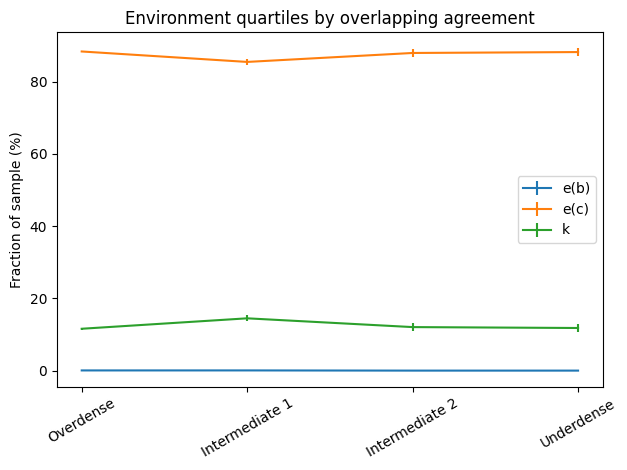

In [9]:
plot_population_vs_environment(analysis_sample, "overlap", "class")

In [10]:
def plot_class_evolution_by_environment(analysis_sample, env_type, mode="redshift"):

    if env_type == "5NN":
        envs = ["Overdense", "Intermediate 1", "Intermediate 2", "Underdense"]
        env_word = "5NN Distance (Mpc)"

    elif env_type == "density":
        envs = ['Underdense', 'Intermediate 2', 'Intermediate 1', 'Overdense']
        env_word = "Num Density ($Num/Mpc^3$)"

    elif env_type == "overlap":
        envs = ["Overdense", "Intermediate 1", "Intermediate 2", "Underdense"]
        env_word = "Overlapping Quartile Agreement"

    else:
        raise ValueError("Invalid env_type")

    if mode not in ["redshift", "mass"]:
        raise ValueError("mode must be 'redshift' or 'mass'")

    classes = sorted(analysis_sample["class"].dropna().unique())
    cmap = plt.get_cmap("tab10")
    class_colors = {cls: cmap(i) for i, cls in enumerate(classes)}

    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
    axes = axes.flatten()

    for ax, env in zip(axes, envs):
        sub_env = analysis_sample[analysis_sample[env_type] == env]

        if sub_env.empty:
            continue

        if mode == "redshift":
            counts = (
                sub_env
                .groupby(["z_bin", "class"], observed=True)
                .size()
                .rename("count")
                .reset_index()
            )

            counts["N"] = counts.groupby("z_bin", observed=True)["count"].transform("sum")
            counts["f"] = counts["count"] / counts["N"]
            counts["x"] = counts["z_bin"].apply(lambda x: x.mid)
            counts["sigma_f"] = np.sqrt(counts["f"] * (1 - counts["f"]) / counts["N"])

            xlabel = "Redshift"

        else:  # mass
            counts = (
                sub_env
                .groupby(["mass_bin", "class"], observed=True)
                .size()
                .rename("count")
                .reset_index()
            )

            counts["N"] = counts.groupby("mass_bin", observed=True)["count"].transform("sum")
            counts["f"] = counts["count"] / counts["N"]
            counts["x"] = counts["mass_bin"].apply(lambda x: x.mid)
            counts["sigma_f"] = np.sqrt(counts["f"] * (1 - counts["f"]) / counts["N"])

            xlabel = r"$\log(M)$"

        class_totals = counts.groupby("class")["count"].sum().to_dict()

        for cls in classes:
            sub = counts[counts["class"] == cls]

            if sub.empty:
                continue

            sub = sub.sort_values("x")

            ax.errorbar(
                sub["x"],
                sub["f"],
                yerr=sub["sigma_f"],
                color=class_colors[cls],
                label=f"{cls} (N={class_totals.get(cls, 0)})"
            )

        ax.set_title(env)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Class Fraction")
        ax.legend(loc="center left")

    fig.suptitle(f"Class Fraction vs {mode.capitalize()} ({env_word})")

    plt.tight_layout()
    plt.savefig(f"../Images/class/{env_type}_class_{mode}.png")
    plt.show()

    return fig

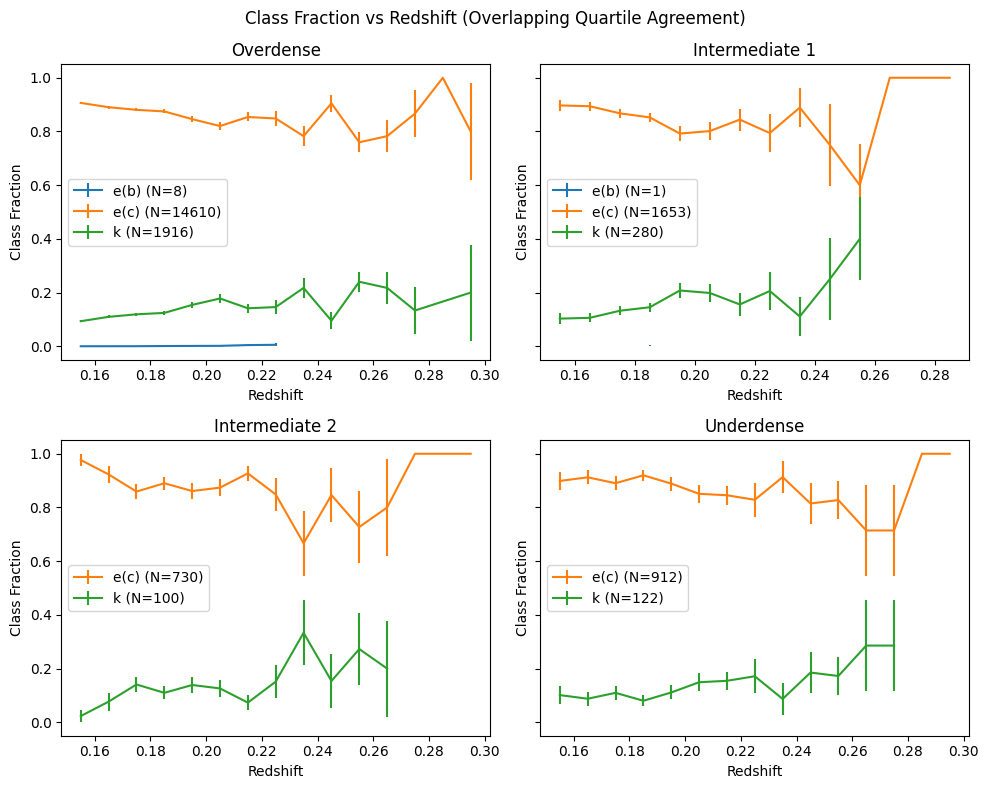

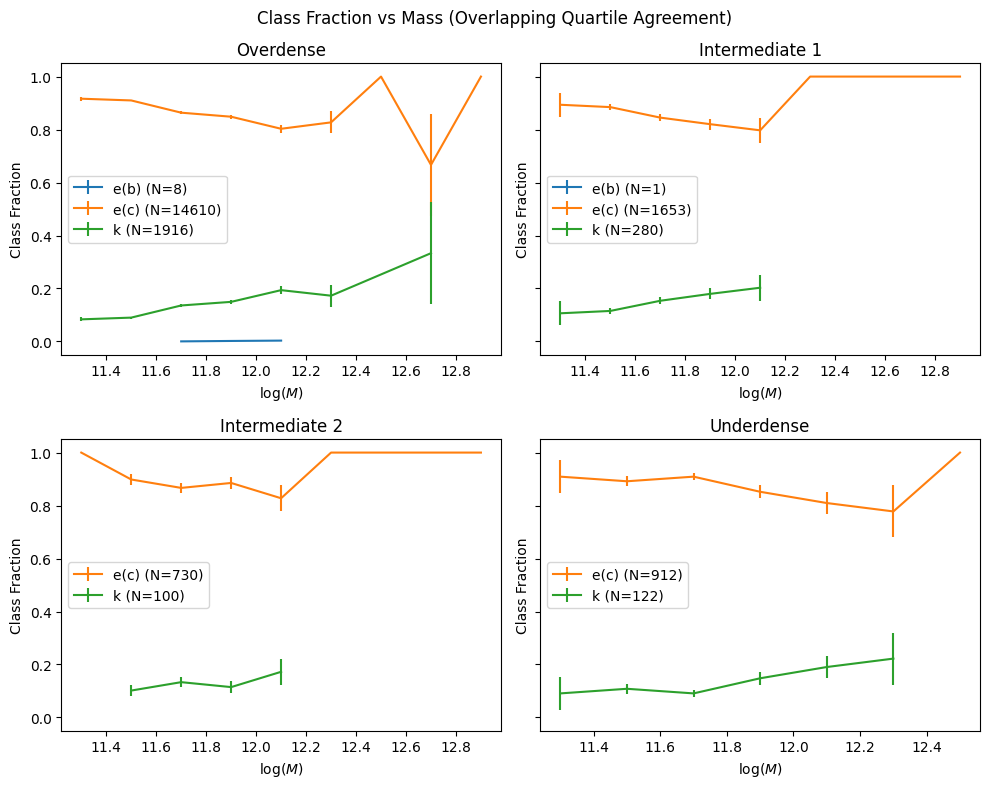

In [11]:
zfig = plot_class_evolution_by_environment(analysis_sample, "overlap", mode="redshift")
mfig = plot_class_evolution_by_environment(analysis_sample, "overlap", mode="mass")

In [12]:
def delta_class_frac(analysis_sample, env_type):
    if env_type == "5NN":
        env_word = "5NN Distance (Mpc)"

    elif env_type == "density":
        env_word = "Num Density ($Num/Mpc^3$)"

    elif env_type == "overlap":
        env_word = "Overlapping Quartile Agreement"

    else:
        raise ValueError("Invalid env_type")
    
    plt_title = fr"$\Delta$ Class fraction by {env_word}"
    image_name = f"../Images/class/{env_type}_class_difference.png"
    
    extremes = ["Overdense", "Underdense"]
    subset = analysis_sample[analysis_sample[env_type].isin(extremes)]

    classes = sorted(subset["class"].dropna().unique())
    cmap = plt.get_cmap("tab10")
    class_colors = {cls: cmap(i) for i, cls in enumerate(classes)}

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=True)
    axes = axes.flatten()

    for cls in classes:
        cls_sub = subset[subset["class"]==cls]
        N_total = len(cls_sub)

        # Compute fractions per bin and environment
        #----------
        #
        # Redshift
        #
        #----------
        z_counts = (
            cls_sub
            .groupby(["z_bin", env_type], observed=True)
            .size()
            .rename("count")
            .reset_index()
        )

        z_totals = (
            subset
            .groupby(["z_bin", env_type], observed=True)
            .size()
            .rename("N")
            .reset_index()
        )

        z_counts = z_counts.merge(z_totals, on=["z_bin", env_type], how="left")

        #z_counts["N"] = z_counts.groupby(["z_bin", env_type], observed=True)["count"].transform("sum")
        z_counts["fraction"] = z_counts["count"] / z_counts["N"]
        z_counts["sigma_f"] = np.sqrt(z_counts["fraction"] * (1 - z_counts["fraction"]) / z_counts["N"])

        z_pivot = z_counts.pivot(index="z_bin", columns=env_type, values="fraction")
        z_pivot["delta_f"] = z_pivot.get("Overdense", 0) - z_pivot.get("Underdense", 0)
        z_sigma = z_counts.pivot(index="z_bin", columns=env_type, values="sigma_f")
        z_sigma["delta_f"] = np.sqrt(z_sigma.get("Overdense", 0)**2 + z_sigma.get("Underdense", 0)**2)

        zx = z_pivot.index.map(lambda x: x.mid)
        zy = z_pivot["delta_f"].values

        #axes[0].plot(zx, zy, label=f"{cls} (N={N_total})", color=class_colors[cls])
        axes[0].errorbar(
            zx,
            zy,
            yerr=z_sigma["delta_f"].values,
            label=f"{cls} (N={N_total})",
            color = class_colors[cls]
        )

        #------
        #
        # Mass
        #
        #------

        mass_counts = (
            cls_sub
            .groupby(["mass_bin", env_type], observed=True)
            .size()
            .rename("count")
            .reset_index()
        )

        mass_totals = (
            subset
            .groupby(["mass_bin", env_type], observed=True)
            .size()
            .rename("N")
            .reset_index()
        )

        mass_counts = mass_counts.merge(mass_totals, on=["mass_bin", env_type], how="left")

        mass_counts["fraction"] = mass_counts["count"] / mass_counts["N"]
        mass_counts["sigma_f"] = np.sqrt(mass_counts["fraction"] * (1 - mass_counts["fraction"]) / mass_counts["N"])
        
        mass_pivot = mass_counts.pivot(index="mass_bin", columns=env_type, values="fraction")
        mass_pivot["delta_f"] = mass_pivot.get("Overdense", 0) - mass_pivot.get("Underdense", 0)
        mass_sigma = mass_counts.pivot(index="mass_bin", columns=env_type, values="sigma_f")
        mass_sigma["delta_f"] = np.sqrt(mass_sigma.get("Overdense", 0)**2 + mass_sigma.get("Underdense", 0)**2)

        massx = mass_pivot.index.map(lambda x: x.mid)
        massy = mass_pivot["delta_f"].values

        axes[1].errorbar(
            massx,
            massy,
            yerr=mass_sigma["delta_f"].values,
            label=f"{cls} (N={N_total})",
            color = class_colors[cls]
        )

    axes[0].set_xlabel("Redshift")
    axes[0].set_ylabel(fr"$\Delta f$ (Cluster-Void)")
    axes[0].axhline(0, linestyle='--', color='black', alpha=0.3)
    axes[1].set_xlabel(r"$\log(M)$")
    axes[1].axhline(0, linestyle='--', color='black', alpha=0.3)
    axes[1].legend()

    fig.suptitle(plt_title)
    plt.tight_layout()
    plt.savefig(image_name)
    plt.show()

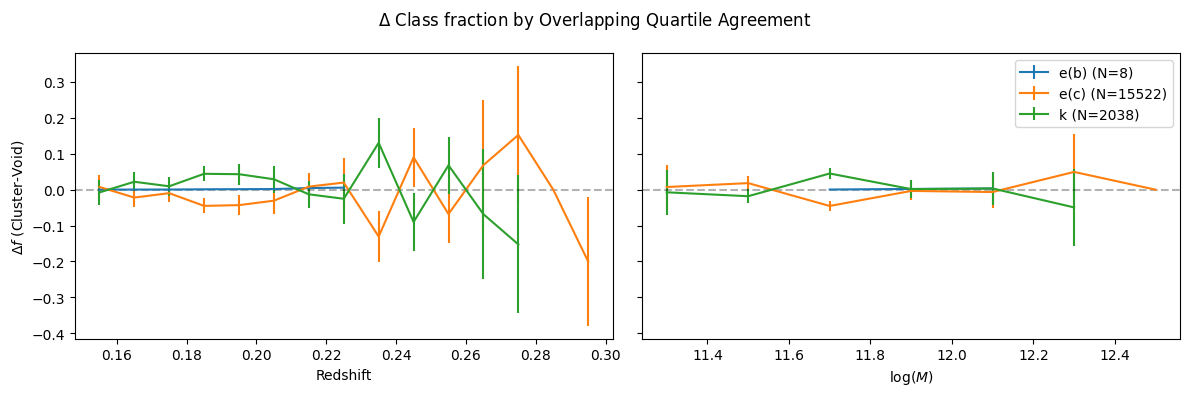

In [13]:
delta_class_frac(analysis_sample, "overlap")